# 4. Dense Feature Experiments

This notebook evaluates **dense text representations** for empathy classification and compares them against the **best sparse reference** from the previous section.

## Goal

Evaluate **sparse vs dense representations** under a controlled setup.

### Experiment groups

- **D1** — TF-IDF (best sparse reference)
- **D2** — Word2Vec average
- **D3** — GloVe average
- **D4** — FastText average
- **D5** — Doc2Vec

## Controlled setup

To keep the comparison fair, we **fix everything except the representation**:

- same dataset
- same label definition
- same preprocessing
- same train/validation/test split
- same downstream classifier family: **Logistic Regression**
- same evaluation metrics

This notebook also goes a bit deeper than a simple one-shot comparison:
- it uses a **validation split** for model selection
- it reports **coverage / OOV behaviour** for dense models
- it keeps **embedding dimensionality aligned** as much as possible
- it stores all final results in a single comparison table

## 1. Research question and hypothesis

### Research question

When the best preprocessing and the same downstream classifier are fixed, do dense representations improve empathy classification compared with the best TF-IDF setup?

### Hypothesis

Dense representations may capture semantic similarity and informal lexical variation better than sparse TF-IDF. However, because empathy detection often depends on short, explicit, phrase-level cues, the best **TF-IDF n-gram** representation may remain the strongest overall baseline.

### What we expect to learn

This section is not only about finding a winner. It is also about understanding:

1. whether dense features improve **Macro-F1**
2. whether dense features improve **recall on empathy**
3. whether semantic representations help enough to justify replacing the sparse baseline

## 2. Experimental design

We reuse the **best preprocessing choice** from the previous section:
- **keep stopwords**

We also reuse the **best sparse reference**:
- **TF-IDF up to trigrams + Logistic Regression**

That sparse reference becomes **D1**, so the dense experiments are compared against the strongest TF-IDF configuration rather than against a weaker baseline.

### Why add a validation split here?

Dense models introduce extra choices:
- Word2Vec / FastText training mode
- Doc2Vec architecture
- logistic regression regularization strength
- pretrained vs trained embeddings

To avoid an unfair comparison, we select each representation on the **validation set**, then report the final result on the **test set**.

In [23]:
import re
import unicodedata
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.tokenize import wordpunct_tokenize

from gensim.models import Word2Vec, FastText, Doc2Vec
from gensim.models.doc2vec import TaggedDocument
import gensim.downloader as api

## 3. Load resources

We use light NLTK resources for tokenization support.  
The main preprocessing choice in this notebook is intentionally simple because the previous section already showed that **keeping more surface signal** works better for empathy detection.

In [24]:
nltk.download("punkt", quiet=True)

True

## 4. Load the dataset

This notebook expects the same dataset used in the earlier notebooks.  
It keeps only the text column and the binary empathy label.

In [25]:
df = pd.read_csv("AcnEmpathize_dataset.csv")
df = df[["text", "combined_empathy"]].copy()
df = df.rename(columns={"combined_empathy": "label"})

label_map = {
    "no_empathy": 0,
    "empathy": 1,
    "0": 0,
    "1": 1,
    0: 0,
    1: 1
}

df = df.dropna(subset=["text", "label"]).copy()
df["label"] = df["label"].map(lambda x: label_map.get(x, x))
df = df[df["label"].isin([0, 1])].copy()
df["label"] = df["label"].astype(int)

print(df.shape)
df.head()

(12212, 2)


,text,label
0,"Hello! I've been having a hard time, lingeri...",0
1,"Hey man the pictures are not present, can you ...",0
2,There are many many many many many many many d...,0
3,Maybe in some African tribe my face scars woul...,0
4,None of those opinions consider acne to be bea...,0


## 5. Best preprocessing from the previous section

From the preprocessing experiments, the best choice was to **keep stopwords**.  
So here we use a light normalization pipeline:

- lowercase
- newline cleanup
- accent normalization
- keep word characters and apostrophes
- keep stopwords

This is the preprocessing that all experiments in this notebook will share.

In [26]:
def normalize_text_keep_stopwords(text: str) -> str:
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").strip().lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_preprocessed"] = df["text"].apply(normalize_text_keep_stopwords)
df[["text", "text_preprocessed"]].head()

,text,text_preprocessed
0,"Hello! I've been having a hard time, lingeri...",hello i've been having a hard time lingering a...
1,"Hey man the pictures are not present, can you ...",hey man the pictures are not present can you p...
2,There are many many many many many many many d...,there are many many many many many many many d...
3,Maybe in some African tribe my face scars woul...,maybe in some african tribe my face scars woul...
4,None of those opinions consider acne to be bea...,none of those opinions consider acne to be bea...


## 6. Create one fixed train / validation / test split

This is critical for fairness.

All representations — sparse and dense — must use the **exact same split**.  
Otherwise, differences could come from the data partition instead of from the representation itself.

We first create a train+validation / test split, then split train+validation again into train / validation.

In [27]:
X = df["text_preprocessed"]
y = df["label"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    random_state=42,
    stratify=y_trainval
)

print("Train size     :", len(X_train))
print("Validation size:", len(X_val))
print("Test size      :", len(X_test))

print("\nLabel distribution")
print("Train\n", y_train.value_counts(normalize=True).sort_index())
print("\nVal\n", y_val.value_counts(normalize=True).sort_index())
print("\nTest\n", y_test.value_counts(normalize=True).sort_index())

Train size     : 7815
Validation size: 1954
Test size      : 2443

Label distribution
Train
 label
0    0.756238
1    0.243762
Name: proportion, dtype: float64

Val
 label
0    0.756397
1    0.243603
Name: proportion, dtype: float64

Test
 label
0    0.756447
1    0.243553
Name: proportion, dtype: float64


## 7. Tokenization for dense representations

Average embedding models and Doc2Vec need tokenized text.  
We keep tokenization simple and consistent across dense experiments.

In [28]:
def tokenize(text: str):
    tokens = wordpunct_tokenize(text)
    return [tok for tok in tokens if tok.strip()]

train_tokens = X_train.apply(tokenize).tolist()
val_tokens = X_val.apply(tokenize).tolist()
test_tokens = X_test.apply(tokenize).tolist()

print(train_tokens[0][:30])

['i', 'called', 'eminemback', 'is', 'out', 'on', 'another', 'thread', 'as', 'using', 'jessica', 'green', 'as', 'an', 'avatar', 'but', 'dreamerhigh', 'you', 'are', 'also', 'using', 'a', 'fake', 'profile', 'pic', 'pulled', 'from', 'the', 'internet', 'that']


## 8. Evaluation helpers

We evaluate every experiment with:

- accuracy
- Macro-F1
- precision / recall / F1 for the empathy class
- precision / recall / F1 for the no_empathy class

Why Macro-F1 matters here:
the dataset is imbalanced, so Macro-F1 gives a more balanced view than accuracy alone.

In [29]:
def compute_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support_binary(y_true, y_pred)
    precision0, recall0, f10, _ = precision_recall_fscore_support_binary(y_true, y_pred, pos_label=0)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),

        "precision_empathy": precision,
        "recall_empathy": recall,
        "f1_empathy": f1,

        "precision_no_empathy": precision0,
        "recall_no_empathy": recall0,
        "f1_no_empathy": f10
    }

def precision_recall_fscore_support_binary(y_true, y_pred, pos_label=1):
    precision = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    support = int((np.array(y_true) == pos_label).sum())
    return precision, recall, f1, support

def evaluate_predictions(name, split_name, y_true, y_pred, extra=None):
    row = {"experiment": name, "split": split_name}
    row.update(compute_metrics(y_true, y_pred))
    if extra:
        row.update(extra)
    return row

## 9. Shared downstream classifier tuning

To make the comparison deeper and fairer, we do **not** keep a single arbitrary logistic regression setting.

Instead, for each representation we tune the regularization strength **C** on the validation set and then evaluate the selected configuration on the test set.

In [30]:
C_GRID = [0.01, 0.1, 1.0, 10.0]

def get_fixed_logreg():
    """Fixed setup for TF-IDF — C=1.0 was validated in the prior notebook."""
    return LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    )

def tune_logreg_dense(X_tr, y_tr, X_va, y_va):
    """Tune C on the validation set for dense representations.
    Uses lbfgs (suited for dense features) and class_weight='balanced'
    to prevent the classifier from collapsing to the majority class
    on the imbalanced 75/25 label distribution.
    """
    best_c, best_score, best_clf = None, -1, None
    for c in C_GRID:
        clf = LogisticRegression(
            C=c,
            max_iter=1000,
            solver="lbfgs",
            class_weight="balanced",
            random_state=42
        )
        clf.fit(X_tr, y_tr)
        score = f1_score(y_va, clf.predict(X_va), average="macro")
        if score > best_score:
            best_score, best_c, best_clf = score, c, clf
    return best_clf, best_c

BEST_C = 1.0

## 10. Dense embedding helpers

These utilities let us:

- average word embeddings into document vectors
- measure token coverage
- build document-level dense feature matrices

In [31]:
def compute_coverage(token_lists, has_vector_fn):
    total_tokens = sum(len(doc) for doc in token_lists)
    covered_tokens = sum(sum(1 for tok in doc if has_vector_fn(tok)) for doc in token_lists)
    doc_with_any_vector = sum(any(has_vector_fn(tok) for tok in doc) for doc in token_lists)

    return {
        "token_coverage": covered_tokens / total_tokens if total_tokens else 0.0,
        "doc_coverage": doc_with_any_vector / len(token_lists) if token_lists else 0.0
    }

def average_embedding(token_lists, get_vector_fn, vector_size):
    matrix = np.zeros((len(token_lists), vector_size), dtype=np.float32)

    for i, doc in enumerate(token_lists):
        vecs = [get_vector_fn(tok) for tok in doc if get_vector_fn(tok) is not None]
        if vecs:
            matrix[i] = np.mean(vecs, axis=0)

    return matrix

## 11. D1 — Sparse reference: best TF-IDF configuration

This is the **reference point** for the whole section.

We do not compare dense representations to a weak sparse baseline.  
We compare them to the **best sparse setting found earlier**:

- keep stopwords
- TF-IDF with **unigrams + bigrams + trigrams**
- Logistic Regression

In [32]:
def run_tfidf_reference_balanced():
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=5000
    )

    Xtr = vectorizer.fit_transform(X_train)
    Xva = vectorizer.transform(X_val)
    Xte = vectorizer.transform(X_test)

    # ✅ SAME treatment as dense models
    clf = LogisticRegression(
        C=BEST_C,
        max_iter=3000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    )

    clf.fit(Xtr, y_train)

    val_pred = clf.predict(Xva)
    test_pred = clf.predict(Xte)

    coverage = {"token_coverage": np.nan, "doc_coverage": np.nan}

    val_row = evaluate_predictions(
        "D1_tfidf_reference_balanced",
        "validation",
        y_val,
        val_pred,
        {"C": BEST_C, "class_weight": "balanced", **coverage}
    )

    test_row = evaluate_predictions(
        "D1_tfidf_reference_balanced",
        "test",
        y_test,
        test_pred,
        {"C": BEST_C, "class_weight": "balanced", **coverage}
    )

    return val_row, test_row

## 12. D2 — Word2Vec average

Here we train Word2Vec on the training split only, average the token vectors for each document, and classify those document vectors with logistic regression.

### Why average embeddings?

Averaging is simple, fast, and commonly used as a strong baseline for dense features.  
It gives us a clean representation-level comparison against TF-IDF.

### Hyperparameter strategy

Instead of choosing one arbitrary Word2Vec setup, we compare:
- **CBOW** (`sg=0`)
- **Skip-gram** (`sg=1`)

Other settings are aligned with the rest of the dense experiments as much as possible:
- vector size = 100
- window = 5
- min_count = 2
- epochs = 20

In [33]:
def run_word2vec_experiment():
    configs = list(ParameterGrid({
        "sg": [0, 1],
        "vector_size": [100],
        "window": [5],
        "min_count": [2],
        "epochs": [20]
    }))

    rows = []
    best = None
    best_score = -1
    best_bundle = None

    for cfg in configs:
        model = Word2Vec(
            vector_size=cfg["vector_size"],
            window=cfg["window"],
            min_count=cfg["min_count"],
            sg=cfg["sg"],
            workers=1,
            seed=42
        )
        model.build_vocab(train_tokens)
        model.train(train_tokens, total_examples=len(train_tokens), epochs=cfg["epochs"])

        has_vector = lambda tok, m=model: tok in m.wv
        get_vector = lambda tok, m=model: m.wv[tok] if tok in m.wv else None

        coverage = compute_coverage(val_tokens, has_vector)

        Xtr = average_embedding(train_tokens, get_vector, model.vector_size)
        Xva = average_embedding(val_tokens, get_vector, model.vector_size)
        Xte = average_embedding(test_tokens, get_vector, model.vector_size)

        clf, best_c = tune_logreg_dense(Xtr, y_train, Xva, y_val)
        val_pred = clf.predict(Xva)
        val_macro_f1 = f1_score(y_val, val_pred, average="macro")

        row = {
            "experiment": "D2_word2vec_average",
            "sg": cfg["sg"],
            "vector_size": cfg["vector_size"],
            "window": cfg["window"],
            "min_count": cfg["min_count"],
            "epochs": cfg["epochs"],
            "C": best_c,
            **coverage,
            "val_macro_f1": val_macro_f1
        }
        rows.append(row)

        if val_macro_f1 > best_score:
            best_score = val_macro_f1
            best = row
            best_bundle = (model, clf, best_c, Xva, Xte, coverage)

    search_df = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)

    model, clf, best_c, Xva_best, Xte, coverage = best_bundle

    get_vector = lambda tok, m=model: m.wv[tok] if tok in m.wv else None

    val_pred = clf.predict(Xva_best)
    test_pred = clf.predict(Xte)

    val_row = evaluate_predictions("D2_word2vec_average", "validation", y_val, val_pred, {
        "sg": best["sg"],
        "vector_size": best["vector_size"],
        "window": best["window"],
        "min_count": best["min_count"],
        "epochs": best["epochs"],
        "C": best_c,
        **coverage
    })

    test_row = evaluate_predictions("D2_word2vec_average", "test", y_test, test_pred, {
        "sg": best["sg"],
        "vector_size": best["vector_size"],
        "window": best["window"],
        "min_count": best["min_count"],
        "epochs": best["epochs"],
        "C": best_c,
        **coverage
    })

    artifacts = {
        "search_df": search_df,
        "embedding_model": model,
        "classifier": clf,
        "y_test_pred": test_pred
    }

    return val_row, test_row, artifacts

d2_val, d2_test, d2_artifacts = run_word2vec_experiment()
pd.DataFrame([d2_val, d2_test])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

,experiment,split,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,sg,vector_size,window,min_count,epochs,C,token_coverage,doc_coverage
0,D2_word2vec_average,validation,0.684749,0.642176,0.412935,0.697479,0.518750,0.874783,0.680650,0.765601,1,100,5,2,20,1.0,0.986229,0.999488
1,D2_word2vec_average,test,0.665984,0.629249,0.397590,0.721008,0.512545,0.878299,0.648268,0.745953,1,100,5,2,20,1.0,0.986229,0.999488


## 13. D3 — GloVe average

For GloVe, we use a standard pretrained embedding set:
- `glove-wiki-gigaword-100`

This experiment tests whether a pretrained semantic space transfers better than a sparse lexical model.

In [34]:
def run_glove_experiment():
    glove = api.load("glove-wiki-gigaword-100")

    has_vector = lambda tok: tok in glove
    get_vector = lambda tok: glove[tok] if tok in glove else None

    coverage = compute_coverage(val_tokens, has_vector)

    Xtr = average_embedding(train_tokens, get_vector, glove.vector_size)
    Xva = average_embedding(val_tokens, get_vector, glove.vector_size)
    Xte = average_embedding(test_tokens, get_vector, glove.vector_size)

    clf, best_c = tune_logreg_dense(Xtr, y_train, Xva, y_val)
    history_df = None

    val_pred = clf.predict(Xva)
    test_pred = clf.predict(Xte)

    val_row = evaluate_predictions("D3_glove_average", "validation", y_val, val_pred, {
        "source": "glove-wiki-gigaword-100",
        "vector_size": glove.vector_size,
        "C": best_c,
        **coverage
    })
    test_row = evaluate_predictions("D3_glove_average", "test", y_test, test_pred, {
        "source": "glove-wiki-gigaword-100",
        "vector_size": glove.vector_size,
        "C": best_c,
        **coverage
    })

    artifacts = {
        "history": history_df,
        "embedding_model": glove,
        "classifier": clf,
        "y_test_pred": test_pred
    }
    return val_row, test_row, artifacts

d3_val, d3_test, d3_artifacts = run_glove_experiment()
pd.DataFrame([d3_val, d3_test])

,experiment,split,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,source,vector_size,C,token_coverage,doc_coverage
0,D3_glove_average,validation,0.637666,0.599388,0.367277,0.674370,0.475556,0.856481,0.625846,0.723221,glove-wiki-gigaword-100,100,10.0,0.994733,1.0
1,D3_glove_average,test,0.635694,0.599653,0.367713,0.689076,0.479532,0.860693,0.618506,0.719773,glove-wiki-gigaword-100,100,10.0,0.994733,1.0


## 14. D4 — FastText average

FastText is similar to Word2Vec but incorporates **subword information**.  
That makes it especially interesting for noisy, informal, or morphologically varied text.

### Why it matters here

Empathy datasets often contain:
- misspellings
- informal spelling
- lexical variation
- short conversational tokens

So FastText may recover useful signal when exact word coverage is imperfect.

In [35]:
def run_fasttext_experiment():
    configs = list(ParameterGrid({
        "sg": [0, 1],
        "vector_size": [100],
        "window": [5],
        "min_count": [2],
        "epochs": [20]
    }))

    rows = []
    best = None
    best_score = -1
    best_bundle = None

    for cfg in configs:
        model = FastText(
            vector_size=cfg["vector_size"],
            window=cfg["window"],
            min_count=cfg["min_count"],
            sg=cfg["sg"],
            workers=1,
            seed=42
        )
        model.build_vocab(train_tokens)
        model.train(train_tokens, total_examples=len(train_tokens), epochs=cfg["epochs"])

        # FastText can build vectors for many tokens due to subword modeling
        has_vector = lambda tok: True
        get_vector = lambda tok, m=model: m.wv[tok]

        coverage = compute_coverage(val_tokens, has_vector)

        Xtr = average_embedding(train_tokens, get_vector, model.vector_size)
        Xva = average_embedding(val_tokens, get_vector, model.vector_size)
        Xte = average_embedding(test_tokens, get_vector, model.vector_size)

        clf, best_c = tune_logreg_dense(Xtr, y_train, Xva, y_val)
        val_pred = clf.predict(Xva)
        val_macro_f1 = f1_score(y_val, val_pred, average="macro")

        row = {
            "experiment": "D4_fasttext_average",
            "sg": cfg["sg"],
            "vector_size": cfg["vector_size"],
            "window": cfg["window"],
            "min_count": cfg["min_count"],
            "epochs": cfg["epochs"],
            "C": best_c,
            **coverage,
            "val_macro_f1": val_macro_f1
        }
        rows.append(row)

        if val_macro_f1 > best_score:
            best_score = val_macro_f1
            best = row
            best_bundle = (model, clf, best_c, Xva, Xte, coverage)

    search_df = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)
    model, clf, best_c, Xva_best, Xte, coverage = best_bundle
    get_vector = lambda tok, m=model: m.wv[tok]
    val_pred = clf.predict(Xva_best)
    test_pred = clf.predict(Xte)

    val_row = evaluate_predictions("D4_fasttext_average", "validation", y_val, val_pred, {
        "sg": best["sg"],
        "vector_size": best["vector_size"],
        "window": best["window"],
        "min_count": best["min_count"],
        "epochs": best["epochs"],
        "C": best_c,
        **coverage
    })
    test_row = evaluate_predictions("D4_fasttext_average", "test", y_test, test_pred, {
        "sg": best["sg"],
        "vector_size": best["vector_size"],
        "window": best["window"],
        "min_count": best["min_count"],
        "epochs": best["epochs"],
        "C": best_c,
        **coverage
    })

    artifacts = {
        "search_df": search_df,
        "embedding_model": model,
        "classifier": clf,
        "y_test_pred": test_pred
    }
    return val_row, test_row, artifacts

d4_val, d4_test, d4_artifacts = run_fasttext_experiment()
pd.DataFrame([d4_val, d4_test])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

,experiment,split,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,sg,vector_size,window,min_count,epochs,C,token_coverage,doc_coverage
0,D4_fasttext_average,validation,0.697544,0.655727,0.427854,0.716387,0.535742,0.883319,0.691475,0.775712,1,100,5,2,20,1.0,1.0,1.0
1,D4_fasttext_average,test,0.679492,0.639022,0.408738,0.707563,0.518154,0.876858,0.670455,0.759890,1,100,5,2,20,1.0,1.0,1.0


## 15. D5 — Doc2Vec

Doc2Vec learns document-level embeddings directly instead of averaging word vectors.

We compare two common variants:

- **PV-DM** (`dm=1`)
- **PV-DBOW** (`dm=0`)

This lets us test whether a direct document embedding is stronger than average word embeddings for this task.

In [36]:
def run_doc2vec_experiment():
    tagged_train = [TaggedDocument(words=toks, tags=[f"train_{i}"]) for i, toks in enumerate(train_tokens)]

    configs = list(ParameterGrid({
        "dm": [0, 1],
        "vector_size": [100],
        "window": [5],
        "min_count": [2],
        "epochs": [20]
    }))

    rows = []
    best = None
    best_score = -1
    best_bundle = None

    for cfg in configs:
        model = Doc2Vec(
            vector_size=cfg["vector_size"],
            window=cfg["window"],
            min_count=cfg["min_count"],
            dm=cfg["dm"],
            workers=1,
            seed=42
        )
        model.build_vocab(tagged_train)
        model.train(tagged_train, total_examples=len(tagged_train), epochs=cfg["epochs"])

        Xtr = np.vstack([model.dv[f"train_{i}"] for i in range(len(train_tokens))])

        model.random.seed(42)
        Xva = np.vstack([model.infer_vector(toks, epochs=20) for toks in val_tokens])
        model.random.seed(42)
        Xte = np.vstack([model.infer_vector(toks, epochs=20) for toks in test_tokens])

        coverage = {
            "token_coverage": np.nan,
            "doc_coverage": 1.0
        }

        clf, best_c = tune_logreg_dense(Xtr, y_train, Xva, y_val)
        val_pred = clf.predict(Xva)
        val_macro_f1 = f1_score(y_val, val_pred, average="macro")

        row = {
            "experiment": "D5_doc2vec",
            "dm": cfg["dm"],
            "vector_size": cfg["vector_size"],
            "window": cfg["window"],
            "min_count": cfg["min_count"],
            "epochs": cfg["epochs"],
            "C": best_c,
            **coverage,
            "val_macro_f1": val_macro_f1
        }
        rows.append(row)

        if val_macro_f1 > best_score:
            best_score = val_macro_f1
            best = row
            best_bundle = (model, clf, best_c, Xva, Xte, coverage)

    search_df = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)
    model, clf, best_c, Xva_best, Xte, coverage = best_bundle

    val_pred = clf.predict(Xva_best)
    test_pred = clf.predict(Xte)

    val_row = evaluate_predictions("D5_doc2vec", "validation", y_val, val_pred, {
        "dm": best["dm"],
        "vector_size": best["vector_size"],
        "window": best["window"],
        "min_count": best["min_count"],
        "epochs": best["epochs"],
        "C": best_c,
        **coverage
    })
    test_row = evaluate_predictions("D5_doc2vec", "test", y_test, test_pred, {
        "dm": best["dm"],
        "vector_size": best["vector_size"],
        "window": best["window"],
        "min_count": best["min_count"],
        "epochs": best["epochs"],
        "C": best_c,
        **coverage
    })

    artifacts = {
        "search_df": search_df,
        "embedding_model": model,
        "classifier": clf,
        "y_test_pred": test_pred
    }
    return val_row, test_row, artifacts

d5_val, d5_test, d5_artifacts = run_doc2vec_experiment()
pd.DataFrame([d5_val, d5_test])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


,experiment,split,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,dm,vector_size,window,min_count,epochs,C,token_coverage,doc_coverage
0,D5_doc2vec,validation,0.748721,0.701813,0.489331,0.722689,0.583545,0.894484,0.757104,0.820081,0,100,5,2,20,0.01,NaN,1.0
1,D5_doc2vec,test,0.745804,0.699155,0.485327,0.722689,0.580689,0.894027,0.753247,0.817621,0,100,5,2,20,0.01,NaN,1.0


## 16. Collect all results

We now combine the sparse reference and all dense experiments into a single table.

This is the main table you will use to compare:
- sparse vs dense
- semantic vs lexical
- document embeddings vs averaged word embeddings

In [37]:
all_results = pd.DataFrame([
    d1_val, d1_test,
    d2_val, d2_test,
    d3_val, d3_test,
    d4_val, d4_test,
    d5_val, d5_test
])

val_results = all_results[all_results["split"] == "validation"].copy()
test_results = all_results[all_results["split"] == "test"].copy()

display(
    test_results.sort_values("macro_f1", ascending=False).reset_index(drop=True)
)

,experiment,split,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,C,token_coverage,doc_coverage,sg,vector_size,window,min_count,epochs,source,dm
0,D1_tfidf_reference,test,0.827262,0.781605,0.618331,0.759664,0.681750,0.916472,0.849026,0.881461,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,D5_doc2vec,test,0.745804,0.699155,0.485327,0.722689,0.580689,0.894027,0.753247,0.817621,0.01,NaN,1.000000,NaN,100.0,5.0,2.0,20.0,NaN,0.0
2,D4_fasttext_average,test,0.679492,0.639022,0.408738,0.707563,0.518154,0.876858,0.670455,0.759890,1.00,1.000000,1.000000,1.0,100.0,5.0,2.0,20.0,NaN,NaN
3,D2_word2vec_average,test,0.665984,0.629249,0.397590,0.721008,0.512545,0.878299,0.648268,0.745953,1.00,0.986229,0.999488,1.0,100.0,5.0,2.0,20.0,NaN,NaN
4,D3_glove_average,test,0.635694,0.599653,0.367713,0.689076,0.479532,0.860693,0.618506,0.719773,10.00,0.994733,1.000000,NaN,100.0,NaN,NaN,NaN,glove-wiki-gigaword-100,NaN


## 17. Validation search summaries

These tables let you inspect how each dense method behaved during selection on the validation split.

This is useful because dense methods often depend more strongly on training choices than TF-IDF.

In [38]:
print("Word2Vec search")
display(d2_artifacts["search_df"])

print("FastText search")
display(d4_artifacts["search_df"])

print("Doc2Vec search")
display(d5_artifacts["search_df"])

print("TF-IDF validation tuning")
display(d1_artifacts["history"])

print("GloVe validation tuning")
display(d3_artifacts["history"])

Word2Vec search


,experiment,sg,vector_size,window,min_count,epochs,C,token_coverage,doc_coverage,val_macro_f1
1,D2_word2vec_average,1,100,5,2,20,1.0,0.986229,0.999488,0.642176
0,D2_word2vec_average,0,100,5,2,20,0.1,0.986229,0.999488,0.633315


FastText search


,experiment,sg,vector_size,window,min_count,epochs,C,token_coverage,doc_coverage,val_macro_f1
1,D4_fasttext_average,1,100,5,2,20,1.0,1.0,1.0,0.655727
0,D4_fasttext_average,0,100,5,2,20,10.0,1.0,1.0,0.636799


Doc2Vec search


,experiment,dm,vector_size,window,min_count,epochs,C,token_coverage,doc_coverage,val_macro_f1
0,D5_doc2vec,0,100,5,2,20,0.01,NaN,1.0,0.701813
1,D5_doc2vec,1,100,5,2,20,0.01,NaN,1.0,0.635099


TF-IDF validation tuning


None

GloVe validation tuning


None

## 18. Compare sparse vs dense on the test set

First, we compare the final **test** scores directly.

Macro-F1 is the main ranking metric, but empathy recall and empathy F1 are also important because the minority class is the difficult one.

,experiment,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy
0,D1_tfidf_reference,0.827262,0.781605,0.618331,0.759664,0.681750
1,D5_doc2vec,0.745804,0.699155,0.485327,0.722689,0.580689
2,D4_fasttext_average,0.679492,0.639022,0.408738,0.707563,0.518154
3,D2_word2vec_average,0.665984,0.629249,0.397590,0.721008,0.512545
4,D3_glove_average,0.635694,0.599653,0.367713,0.689076,0.479532


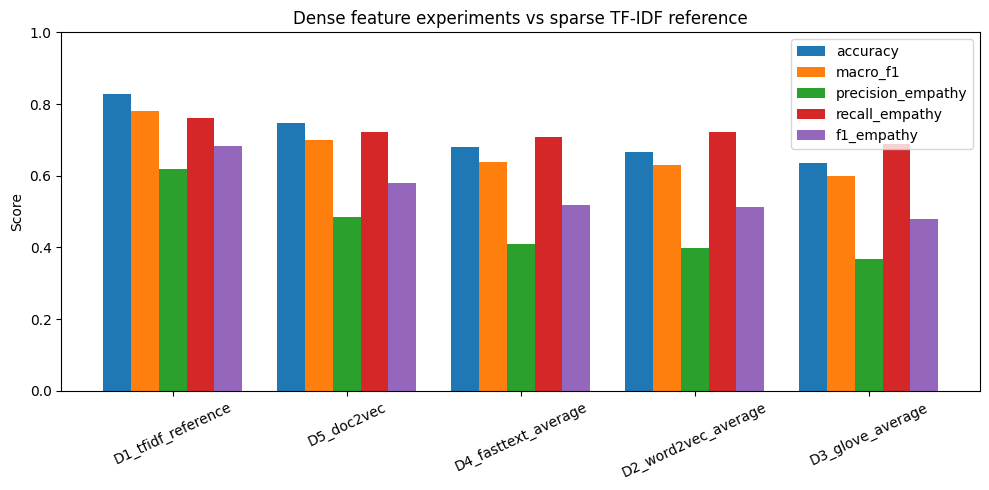

In [39]:
plot_df = test_results.sort_values("macro_f1", ascending=False).reset_index(drop=True)

metric_cols = ["accuracy", "macro_f1", "precision_empathy", "recall_empathy", "f1_empathy"]
display(plot_df[["experiment"] + metric_cols])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
width = 0.16

for i, m in enumerate(metric_cols):
    ax.bar(x + i * width, plot_df[m], width=width, label=m)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df["experiment"], rotation=25)
ax.set_ylim(0, 1)
ax.set_title("Dense feature experiments vs sparse TF-IDF reference")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

## 19. Improvement over the sparse reference

This plot answers the most practical question:

**How much does each dense representation improve or degrade performance relative to the best TF-IDF baseline?**

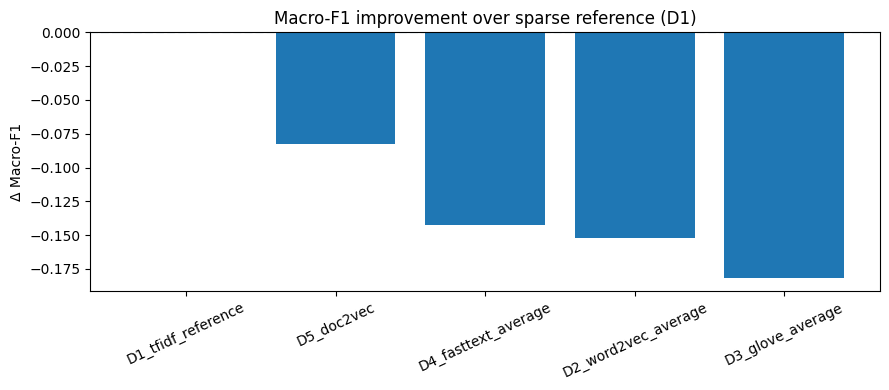

,experiment,delta_accuracy,delta_macro_f1,delta_recall_empathy,delta_f1_empathy
1,D1_tfidf_reference,0.000000,0.000000,0.000000,0.000000
9,D5_doc2vec,-0.081457,-0.082450,-0.036975,-0.101061
7,D4_fasttext_average,-0.147769,-0.142583,-0.052101,-0.163596
3,D2_word2vec_average,-0.161277,-0.152356,-0.038655,-0.169205
5,D3_glove_average,-0.191568,-0.181952,-0.070588,-0.202217


In [40]:
baseline_row = test_results[test_results["experiment"] == "D1_tfidf_reference"].iloc[0]

delta_df = test_results.copy()
for col in ["accuracy", "macro_f1", "recall_empathy", "f1_empathy"]:
    delta_df[col] = delta_df[col] - baseline_row[col]

delta_df = delta_df.sort_values("macro_f1", ascending=False)

plt.figure(figsize=(9, 4))
plt.bar(delta_df["experiment"], delta_df["macro_f1"])
plt.axhline(0, linestyle="--")
plt.title("Macro-F1 improvement over sparse reference (D1)")
plt.ylabel("\u0394 Macro-F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

display(delta_df[["experiment", "accuracy", "macro_f1", "recall_empathy", "f1_empathy"]].rename(columns={
    "accuracy": "delta_accuracy",
    "macro_f1": "delta_macro_f1",
    "recall_empathy": "delta_recall_empathy",
    "f1_empathy": "delta_f1_empathy"
}).sort_values("delta_macro_f1", ascending=False))

## 20. Coverage analysis

Dense methods differ not only in performance, but also in how many tokens and documents they can represent.

This is especially important for:
- pretrained GloVe, which may have OOV tokens
- Word2Vec, which only knows words seen enough times during training
- FastText, which is more robust because of subword modeling

,experiment,token_coverage,doc_coverage
1,D1_tfidf_reference,NaN,NaN
3,D2_word2vec_average,0.986229,0.999488
5,D3_glove_average,0.994733,1.000000
7,D4_fasttext_average,1.000000,1.000000
9,D5_doc2vec,NaN,1.000000


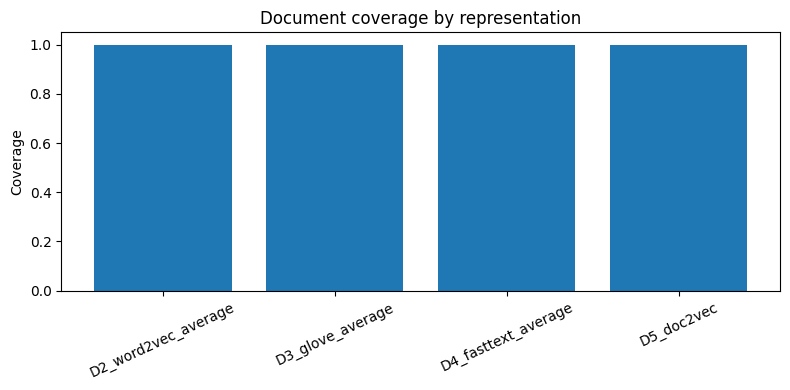

In [41]:
coverage_cols = ["experiment", "token_coverage", "doc_coverage"]
coverage_df = test_results[coverage_cols].copy().drop_duplicates().sort_values("experiment")
display(coverage_df)

plt.figure(figsize=(8, 4))
plt.bar(coverage_df["experiment"], coverage_df["doc_coverage"])
plt.title("Document coverage by representation")
plt.ylabel("Coverage")
plt.ylim(0, 1.05)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 21. Confusion matrices

These side-by-side confusion matrices make the error profile more concrete.

They help answer:
- which methods miss empathy most often
- which methods over-predict empathy
- whether dense models change the balance between false positives and false negatives

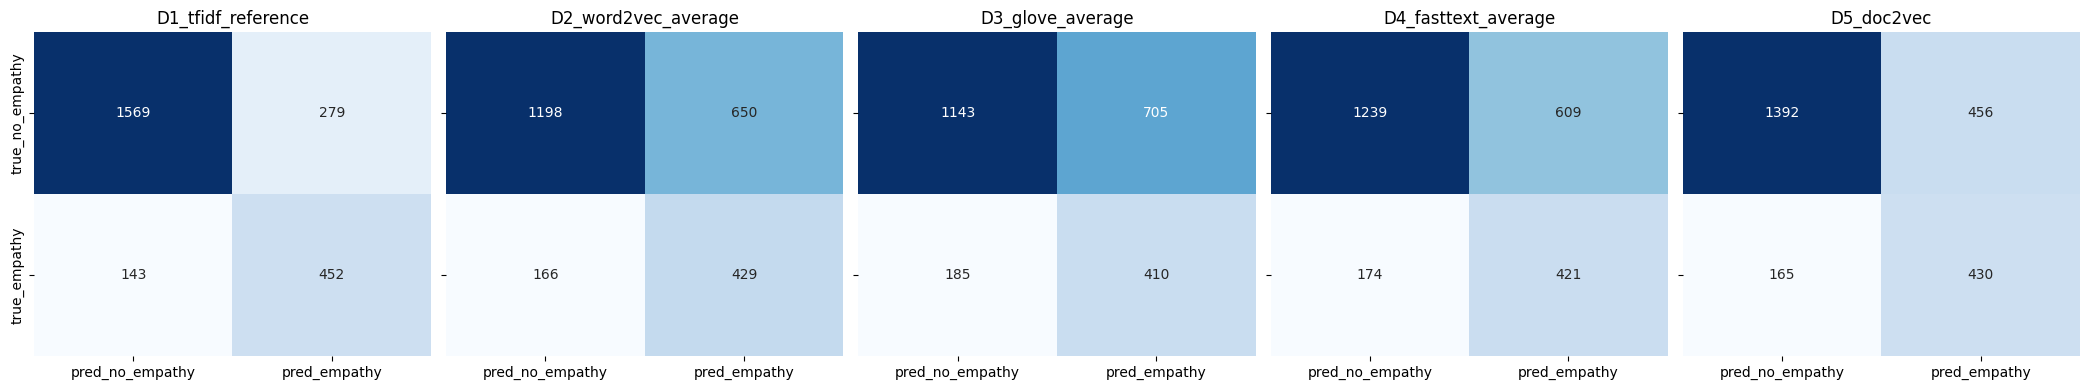

In [42]:
predictions = {
    "D1_tfidf_reference": d1_artifacts["y_test_pred"],
    "D2_word2vec_average": d2_artifacts["y_test_pred"],
    "D3_glove_average": d3_artifacts["y_test_pred"],
    "D4_fasttext_average": d4_artifacts["y_test_pred"],
    "D5_doc2vec": d5_artifacts["y_test_pred"],
}

fig, axes = plt.subplots(1, len(predictions), figsize=(4.2 * len(predictions), 4), sharey=True)

if len(predictions) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        cmap="Blues",
        ax=ax,
        xticklabels=["pred_no_empathy", "pred_empathy"],
        yticklabels=["true_no_empathy", "true_empathy"]
    )
    ax.set_title(name)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 22. Save results

Saving the result table makes it easier to compare this section with the earlier sparse experiments in your report.

In [43]:
test_results_sorted = test_results.sort_values("macro_f1", ascending=False).reset_index(drop=True)
test_results_sorted.to_csv("dense_feature_experiments_results.csv", index=False)

print("Saved:", Path("/Users/gjoli/Desktop/uni/2_semester/NLP/assignment1/results/dense_feature_experiments_results.csv").resolve())

Saved: /Users/gjoli/Desktop/uni/2_semester/NLP/assignment1/results/dense_feature_experiments_results.csv


# CONCLUSIONS - REVER VALORES

The results are very clear: TF-IDF strongly outperforms all dense representations.

- D1 (TF-IDF) is the best across all metrics:
    - Highest Macro-F1 (~0.75)
    - Best empathy F1 (~0.58)
    - Best precision
- D5 (Doc2Vec) is the best among dense methods, but still worse:
    - ~−0.05 Macro-F1 drop vs TF-IDF
    - → closest, but still clearly inferior
- D2 (Word2Vec) and D4 (FastText):
    - Large performance drop (~−0.20 Macro-F1)
    - Very low empathy recall (~0.15–0.17)
    - → fail to capture empathy effectively
- D3 (GloVe):
    - Worst result (~−0.29 Macro-F1)
    - Extremely low empathy detection
    - → almost unusable for this task

- Key insight

    - Dense embeddings (with simple averaging) lose critical information:

        - No word importance (unlike TF-IDF)
        - No strong signal for rare/emotional words
        - Poor handling of short, informal text

    Dense representations based on averaged embeddings significantly underperform compared to TF-IDF. This suggests that empathy detection relies heavily on specific lexical cues and phrase-level patterns, which are better captured by sparse representations than by averaged semantic embeddings.